# Sensors

The BNO085 on SPI2, the A1335 on SPI4: what each reports, what each refuses, whether there is a magnet.

## 1 Setup

In [1]:
from coaxial import ExecutionMode

MODE = ExecutionMode.SIMULATED   # .HARDWARE, and PORT, at the bench; .EMULATED: the image on Renode
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, execution_mode=MODE).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 2 The rail both parts hang on

AFE_ON powers the ADC reference, the BNO085 and the A1335 (`0x6D` kind 4, column `power`). Unpowered, the BNO085 still advertises and ignores writes (FINDINGS). `settled()` waits for each loop to say `running`. The stand-in answers with the rail off; a board refuses.

In [3]:
from coaxial.errors import RigError

parts = device.system.channel_map()['parts']
powered = [p for p in parts if p['power'] == 'AFE_ON']
for p in powered:
    print('%-16s %-24s %-16s %s' % (p['name'], p['what'], p['where'], p['state']))
imu = device.imu
angle = device.angle
rail = device.afe.state()
try:
    with imu.configuring():
        answer = imu.product_id()
    print('rail on=%s: product id answered, version %s, reset cause %s'
          % (rail['on'], answer['sw_version'], answer['reset_cause_name']))
except RigError as exc:
    print('rail on=%s: refused - %s' % (rail['on'], exc))

BNO085           9-axis IMU, SHTP         SPI2, U13        ready
A1335            magnetic angle sensor    SPI4, U14        ready
NTC              thermistor               ADC3             ready
DC link divider  49.9k/2.2k, 78.15 V FS   ADC              ready
rail on=False: product id answered, version simulated, reset cause power on reset


In [4]:
daq = device.daq
daq.enable()
rail = device.afe.state()
print(rail)
print('IMU loop running:', imu.settled(), ' angle loop running:', angle.settled())

{'on': True, 'pe15': False, 'users': ['host']}
IMU loop running: True  angle loop running: True


## 3 SPI2 belongs to the poll loop

Every call that drives SPI2 refuses while the loop runs - on a board; the stand-in answers. `configuring()` holds it for the block. Pins: `bits` 15 = followed the MCU every way.

In [5]:
try:
    print('while running: answered, version', imu.product_id()['sw_version'])
except RigError as exc:
    print('while running: refused -', exc)
with imu.configuring():
    print('in the block:', imu.state()['loop'])
    ident = imu.product_id()
    pins = imu.pins()
    wake = imu.wake_test()
    probe = imu.probe()
    drained = imu.reset()
print('after:', imu.state()['loop'], ' settled:', imu.settled())
print(ident)
for p in pins:
    print('  %-5s %-10s bits %2d  held %s' % (p['pin'], p['signal'], p['bits'], p['held']))
print('wake   %s ms' % wake)
print('probe  %s at %d bit/s off a %d Hz kernel'
      % (probe['raw'].hex(' '), probe['bitrate_hz'], probe['kernel_hz']))
print('reset  produced %d cargoes' % drained)

while running: answered, version simulated
in the block: held
after: running  settled: True
{'reset_cause': 1, 'reset_cause_name': 'power on reset', 'sw_version': 'simulated', 'sw_part': 0, 'sw_build': 0, 'sw_patch': 0}
  PB12  NSS/H_CSN  bits 15  held False
  PB13  SCK        bits 15  held False
  PB14  MISO       bits 15  held False
  PB15  MOSI       bits 15  held False
wake   0 ms
probe  00 00 00 00 at 1484375 bit/s off a 190000000 Hz kernel
reset  produced 3 cargoes


`00 00 00 00` off the bus: present, idle; `ff ff ff ff`: absent or in reset. A reset gives three cargoes: the advertisement and two announcements.

## 4 The rotation vector

Report 0x05 at 20 000 us, big-endian; 0 disables. A write into a part still announcing itself is lost (SERVER DEVICE FAILURE): the firmware drains first (FINDINGS).

In [6]:
import time

from coaxial.devices.imu import ROTATION_VECTOR

imu.configure({ROTATION_VECTOR: 20000})
waited = 0.0
while imu.read() is None and waited < 2.0:
    time.sleep(0.02)                    # one report interval
    waited += 0.02
first = imu.state()
second = imu.state()
for st in (first, second):
    q = st['quaternion']
    print('%-8s updates %6d  %s, %s accuracy  %s'
          % (st['loop'], st['updates'], st.get('name'), st.get('accuracy'),
             None if q is None else {k: round(v, 3) for k, v in q.items()}))
print('feature asked:', first['feature'], ' first report after %.2f s' % waited)
print('error %s, last fault %s (id %d), cargoes %d, errors %d'
      % (second['error'], second['last_fault'], second['last_fault_id'],
         second['cargoes'], second['errors']))

running  updates      0  rotation vector, high accuracy  {'i': 0.073, 'j': 0.146, 'k': -0.011, 'real': 0.986}
running  updates      0  rotation vector, high accuracy  {'i': 0.085, 'j': 0.17, 'k': -0.015, 'real': 0.982}
feature asked: {'report_id': 5, 'interval_us': 20000, 'pending': False}  first report after 0.00 s
error none, last fault none (id 0), cargoes 0, errors 0


## 5 The three vectors

Accelerometer Q8 m/s^2, gyroscope Q9 rad/s, magnetometer Q4 uT; a feature not enabled is None, not zero. At rest: 1 g, no rate, 25-65 uT.

In [7]:
import math

from coaxial.devices.imu import ACCELEROMETER, GYROSCOPE, MAGNETIC_FIELD

VECTORS = ('accelerometer', 'gyroscope', 'magnetometer')
before = imu.state()
for name in VECTORS:
    print('%-14s %s' % (name, before[name]))
imu.configure(dict.fromkeys((ACCELEROMETER, GYROSCOPE, MAGNETIC_FIELD), 20000))
vectors = imu.state()
vectors_waited = 0.0
while any(vectors[n] is None for n in VECTORS) and vectors_waited < 2.0:
    time.sleep(0.02)                    # one report interval
    vectors_waited += 0.02
    vectors = imu.state()
print('all three after %.2f s' % vectors_waited)
magnitude = {}
for name in VECTORS:
    v = vectors[name]
    magnitude[name] = math.sqrt(sum(c * c for c in v['value'].values()))
    print('%-14s %-5s %-6s x %8.3f  y %8.3f  z %8.3f  |v| %7.3f  counts %s'
          % (name, v['accuracy'], v['unit'], v['value']['x'], v['value']['y'],
             v['value']['z'], magnitude[name], v['counts']))

accelerometer  None
gyroscope      None
magnetometer   None
all three after 0.00 s
accelerometer  high  m/s^2  x   -0.034  y    0.001  z    9.823  |v|   9.823  counts {'x': -8, 'y': 0, 'z': 2514}
gyroscope      high  rad/s  x    0.003  y    0.042  z   -0.011  |v|   0.043  counts {'x': 1, 'y': 21, 'z': -5}
magnetometer   high  uT     x   21.998  y   -2.981  z   41.005  |v|  46.628  counts {'x': 351, 'y': -47, 'z': 656}


## 6 The board at that attitude

The quaternion as the BOARD ATTITUDE page draws it; the part sends i, j, k, real.

{'i': 0.119, 'j': 0.241, 'k': -0.03, 'real': 0.963}


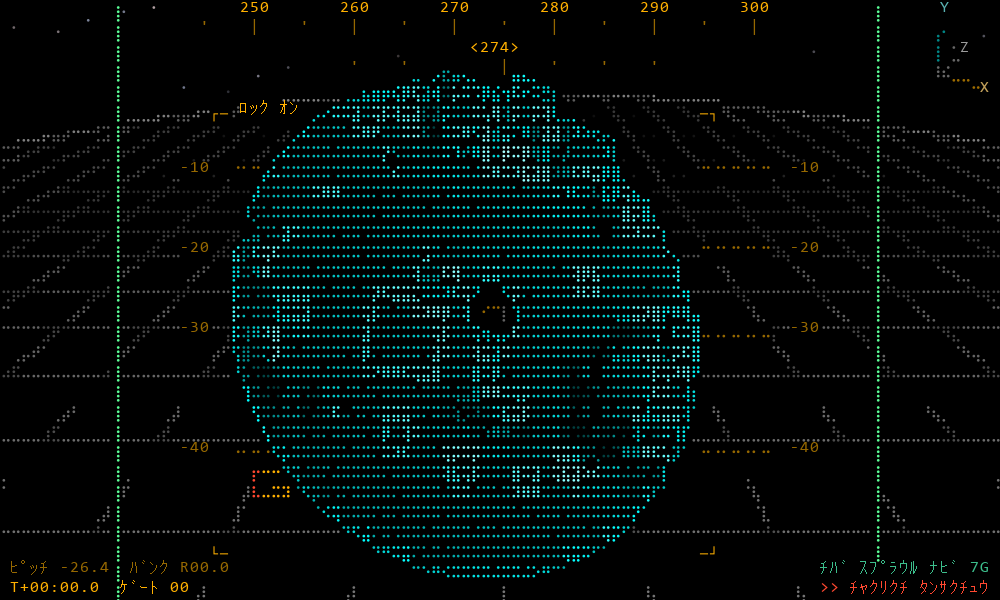

In [8]:
from coaxial.draw import orientation
from machine import ansi

q = imu.state()['quaternion']
print({k: round(v, 3) for k, v in q.items()})
ansi.image(orientation.render((q['i'], q['j'], q['k'], q['real']), 100, 30, wire=True, colour=True))

## 7 The A1335: six registers

A1335: ANG 0x20, STA 0x22, ERR 0x24, XERR 0x26, TSEN 0x28, FIELD 0x2A. Twelve bits: ANG 360/4096 deg, TSEN 1/8 K, FIELD 1 G. `state()` reads the loop's record, no SPI.

In [9]:
from coaxial.devices.angle import (ANG, ERR, FIELD, STA, TSEN, XERR, counts, degrees,
                                   gauss, kelvin)
from coaxial.devices.scaling import KELVIN_AT_ZERO_C

st = angle.state()
print({k: st.get(k) for k in ('loop', 'updates', 'errors', 'register_name', 'value', 'degrees', 'crc')})
clock = angle.clock()
print('SPI4 %d bit/s off a %d Hz kernel' % (clock['bitrate_hz'], clock['kernel_hz']))
with angle.configuring():
    print('in the block:', angle.state()['loop'])
    got = {reg: angle.peek(reg) for reg in (ANG, STA, ERR, XERR, TSEN, FIELD)}
print('after:', angle.state()['loop'])
for r in got.values():
    print('%-5s 0x%04X  data %4d  flags 0x%X  crc %d'
          % (r['register_name'], r['value'], counts(r['value']), r['value'] >> 12, r['crc']))
ang, tsen, field = (got[reg]['value'] for reg in (ANG, TSEN, FIELD))
print('angle  %.2f deg' % degrees(ang))
print('die    %.1f K = %.1f C' % (kelvin(tsen), kelvin(tsen) - KELVIN_AT_ZERO_C))
print('field  %.0f G' % gauss(field))

{'loop': 'running', 'updates': 74, 'errors': 0, 'register_name': 'ANG', 'value': 21350, 'degrees': 76.46484375, 'crc': 0}
SPI4 1855468 bit/s off a 118750000 Hz kernel
in the block: held
after: running
ANG   0x5366  data  870  flags 0x5  crc 0
STA   0x8000  data    0  flags 0x8  crc 0
ERR   0x8000  data    0  flags 0x8  crc 0
XERR  0x8000  data    0  flags 0x8  crc 0
TSEN  0xF951  data 2385  flags 0xF  crc 0
FIELD 0xE17C  data  380  flags 0xE  crc 0
angle  76.46 deg
die    298.1 K = 25.0 C
field  380 G


No magnet: ~2 G. The datasheet's band: 300-1000 G. The stand-in: 380 G.

## 8 The dial

The SHAFT ANGLE dial: ANG, the die on -40..150 C, the field on 0..1200 G; no needle below 30 G (`dial.WEAK_GAUSS`).

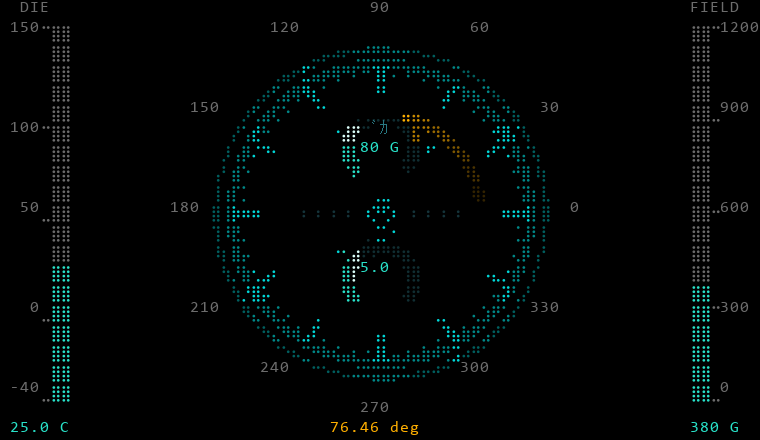

In [10]:
from coaxial.draw import dial

ansi.image(dial.instrument(degrees(ang), gauss(field), kelvin(tsen), colour=True))

## 9 Both parts in one record

Sensor snapshots ride any software-clocked record beside the sums (MINOR 7); a record needs one analog channel, here the NTC. The shaft's rate off record stamps, not a wall clock.

In [11]:
print(device.set_time_from_pc(reference='pc'))
layout = daq.configure('NTC', 'shaft angle', 'orientation', sample_rate=50)
print(layout['sensors'])
daq.start()
run = daq.read(100)
daq.stop()
df = daq.frame(run, index='elapsed', scaled=True)
present = int(df['shaft angle have'].sum())
print('%d records, stride %d bytes; shaft snapshot present in %d of %d'
      % (len(run), layout['stride'], present, len(df)))
print(run[0]['sensors'])

<Sync 474.985230 MHz (-31.1 ppm vs pc, floor 0.1 ppm), reference +/- 0 us>
[{'bit': 0, 'words': 4, 'signal': 'orientation'}, {'bit': 4, 'words': 4, 'signal': 'shaft angle'}]


100 records, stride 35 bytes; shaft snapshot present in 100 of 100
{'orientation': (2125, 4330, -588, 15646), 'shaft angle': (22413, 0, 32, 1)}


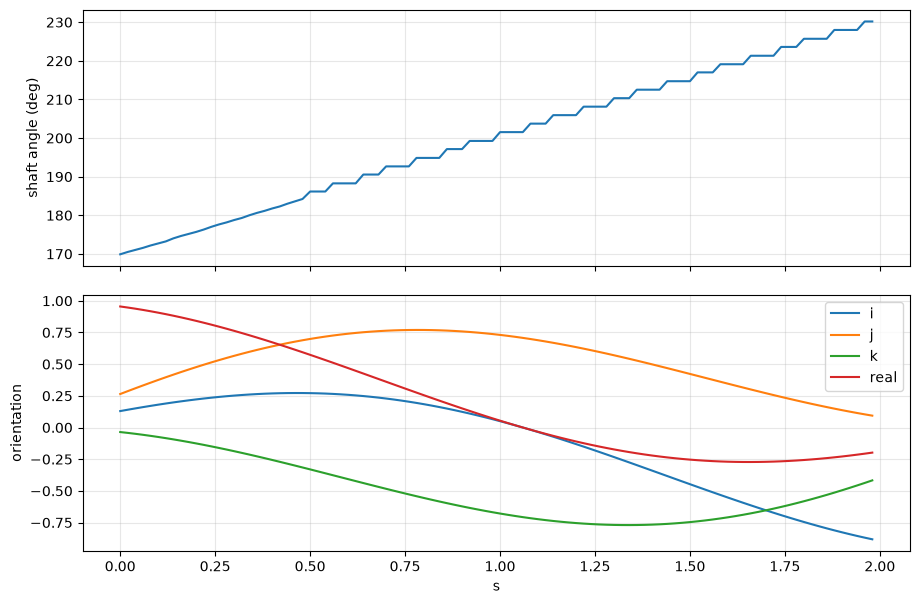

In [12]:
from coaxial.draw.figures import figure, show

axes = ['orientation %s (unit)' % w for w in ('i', 'j', 'k', 'real')]
fig, (top, bottom) = figure(rows=2, sharex=True)
top.plot(df.index, df['shaft angle (deg)'])
top.set_ylabel('shaft angle (deg)')
for column in axes:
    bottom.plot(df.index, df[column], label=column.split()[1])
bottom.set_ylabel('orientation')
bottom.legend(loc='upper right')
bottom.set_xlabel('s')
show(fig)

In [13]:
turned = [df['shaft angle (deg)'].iloc[0]]
for reading in df['shaft angle (deg)'].iloc[1:]:
    turned.append(turned[-1] + (reading - turned[-1] % 360.0 + 180.0) % 360.0 - 180.0)
span = df.index[-1] - df.index[0]
rate = (turned[-1] - turned[0]) / span
norm = (df[axes] ** 2).sum(axis=1) ** 0.5
print('shaft  %.2f deg over %.2f s = %.1f deg/s' % (turned[-1] - turned[0], span, rate))
print('|q|    %.4f to %.4f over %d records' % (norm.min(), norm.max(), len(norm)))
imu.configure(dict.fromkeys((ROTATION_VECTOR, ACCELEROMETER, GYROSCOPE, MAGNETIC_FIELD), 0))
imu_final = imu.state()
angle_final = angle.state()
print('features off; IMU loop %s, angle loop %s' % (imu_final['loop'], angle_final['loop']))

shaft  60.29 deg over 1.98 s = 30.5 deg/s
|q|    0.9999 to 1.0000 over 100 records
features off; IMU loop running, angle loop running


In [14]:
device.close()
print(device)

<Coaxial63100 Simulated closed SIMULATED>


## 10 Results

In [15]:
print('1. rail       AFE_ON powers %d of %d listed parts (%s); on=%s, users %s'
      % (len(powered), len(parts), ', '.join(p['name'] for p in powered),
         rail['on'], rail['users']))
print('2. SPI2       %d pins, %d held; wake %s ms; bus %s; reset produced %d cargoes'
      % (len(pins), sum(p['held'] for p in pins), wake, probe['raw'].hex(' '), drained))
print('3. rotation   report 0x%02X at %d us, pending %s; first report after %.2f s; '
      'updates +%d between two reads; %s accuracy; |q| %.4f'
      % (first['feature']['report_id'], first['feature']['interval_us'],
         first['feature']['pending'], waited, second['updates'] - first['updates'],
         second['accuracy'],
         math.sqrt(sum(v * v for v in second['quaternion'].values()))))
print('4. vectors    before enabling: %s; all three after %.2f s: |a| %.2f m/s^2, |w| %.3f rad/s, '
      '|B| %.1f uT'
      % (', '.join(str(before[n]) for n in VECTORS), vectors_waited, magnitude['accelerometer'],
         magnitude['gyroscope'], magnitude['magnetometer']))
print('5. A1335      ANG 0x%04X = %.2f deg; TSEN 0x%04X = %.1f K = %.1f C; '
      'FIELD 0x%04X = %.0f G, %s; CRC %d reported, not checked; SPI4 %.3f Mbit/s off %.2f MHz'
      % (ang, degrees(ang), tsen, kelvin(tsen), kelvin(tsen) - KELVIN_AT_ZERO_C,
         field, gauss(field),
         'no magnet' if gauss(field) < dial.WEAK_GAUSS else 'a magnet in place',
         got[ANG]['crc'], clock['bitrate_hz'] / 1e6, clock['kernel_hz'] / 1e6))
print('6. record     %d records at 50/s, stride %d bytes; shaft %.2f deg over %.2f s = %.1f deg/s; '
      'snapshot in %d of %d; |q| %.4f to %.4f'
      % (len(run), layout['stride'], turned[-1] - turned[0], span, rate, present,
         len(df), norm.min(), norm.max()))
print('7. loops      IMU %s: updates %d, cargoes %d, errors %d, last fault %s (id %d); '
      'angle %s: updates %d, errors %d'
      % (imu_final['loop'], imu_final['updates'], imu_final['cargoes'], imu_final['errors'],
         imu_final['last_fault'], imu_final['last_fault_id'], angle_final['loop'],
         angle_final['updates'], angle_final['errors']))

1. rail       AFE_ON powers 4 of 10 listed parts (BNO085, A1335, NTC, DC link divider); on=True, users ['host']
2. SPI2       4 pins, 0 held; wake 0 ms; bus 00 00 00 00; reset produced 3 cargoes
3. rotation   report 0x05 at 20000 us, pending False; first report after 0.00 s; updates +0 between two reads; high accuracy; |q| 1.0000
4. vectors    before enabling: None, None, None; all three after 0.00 s: |a| 9.82 m/s^2, |w| 0.043 rad/s, |B| 46.6 uT
5. A1335      ANG 0x5366 = 76.46 deg; TSEN 0xF951 = 298.1 K = 25.0 C; FIELD 0xE17C = 380 G, a magnet in place; CRC 0 reported, not checked; SPI4 1.855 Mbit/s off 118.75 MHz
6. record     100 records at 50/s, stride 35 bytes; shaft 60.29 deg over 1.98 s = 30.5 deg/s; snapshot in 100 of 100; |q| 0.9999 to 1.0000
7. loops      IMU running: updates 452, cargoes 452, errors 0, last fault none (id 0); angle running: updates 185, errors 0


- Three refusals, all the board's: AFE_ON low, the poll loop running, a part still announcing (FINDINGS).
- A1335 reads are two frames: the address in the first, the answer in the second.
- TSEN is the part's die: NTC - TSEN -0.74 C idle, +10.94 C switching (2026-08-28).

**Bench.** Wait on `settled()` before any Set Feature. Read FIELD before ANG: ~2 G is no magnet.

## References

* `host/coaxial/devices/imu.py` - the BNO085 host side: report lengths, Q points, and the refusal explained
* `host/coaxial/devices/angle.py` - the A1335 host side: the register map, the twelve bits as degrees, kelvin and gauss
* `host/coaxial/devices/sensor.py` - `PolledSensor`: `state`, `hold`, `resume`, `configuring`, `settled`
* `host/coaxial/simulated/sensors.py` - the stand-in this ran on: a BNO085 that tumbles and an A1335 that follows the simulated shaft
* `board/src/board_imu.c` - the SPI2 poll loop, the drain before a write, the refusal while PB2 is low
* `board/src/board_angle.c` - the SPI4 loop and the two-frame read
* `docs/PROTOCOL.md` - devices 0 and 1 on the wire; op 8's appended vectors (MINOR 6); the record's snapshots (MINOR 7)
* `docs/FINDINGS.md` - AFE and ADC, IMU (BNO085), A1335: what was measured and ruled out